# PHÂN TÍCH KHÁM PHÁ DỮ LIỆU CHUYÊN SÂU (EDA): OHLCV 1D & 1M
## Khảo sát Cấu trúc Vi mô và Chất lượng Dữ liệu trên Cổ phiếu Mẫu (FPT)

**Dự án:** VESTA - Vietnamese Equity Sentiment-Triggered Agent  
**Mục tiêu phân hệ:** Data Quality & Preprocessing (Trước bước F101 Cross-Reference Validation)  
**Mã khảo sát mẫu:** `FPT` (Công ty Cổ phần FPT - Mã cổ phiếu đầu ngành công nghệ, thanh khoản cao, lịch sử giao dịch liên tục từ 2006 đến 2026)

---

### Mục tiêu nghiên cứu:
1. **Dữ liệu 1D (Daily):** Đánh giá tính toàn vẹn (missing dates, zero-volume/zero-price do ngày tạm ngừng giao dịch), phân phối lợi suất (fat tails, biên độ trần/sàn HOSE $\pm 7\%$) và cơ chế điều chỉnh giá (Raw vs Adjusted Close).
2. **Dữ liệu 1M (Intraday Minute):** Kiểm tra chuỗi thời gian nến phút, phát hiện và phân tích hiện tượng **lệch múi giờ UTC vs UTC+7** từ nhà cung cấp dữ liệu, khảo sát quy luật thanh khoản hình chữ U (U-shaped intraday volume pattern) giữa các phiên ATO, liên tục và ATC.

In [11]:
# 1. Khởi tạo môi trường và nạp các thư viện phân tích định lượng
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

# Cấu hình hiển thị và giao diện biểu đồ chuyên nghiệp
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial']
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

# Đường dẫn cơ sở dữ liệu DuckDB VESTA
DB_PATH = '../../db/vesta_ohlcv.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)
print("✅ Đã kết nối thành công DuckDB:", DB_PATH)

✅ Đã kết nối thành công DuckDB: ../../db/vesta_ohlcv.duckdb


--- 
## PHẦN I: KHẢO SÁT CHUYÊN SÂU DỮ LIỆU DAILY OHLCV (1D)
Trích xuất toàn bộ chuỗi giá hàng ngày của `FPT` từ bảng `core.market_ohlcv_daily`.

In [12]:
# 1.1 Tải toàn bộ chuỗi nến ngày 1D của FPT
query_1d = """
    SELECT symbol, date, open, high, low, close, volume
    FROM core.market_ohlcv_daily
    WHERE symbol = 'FPT'
    ORDER BY date ASC
"""
df_1d = con.execute(query_1d).fetchdf()
df_1d['date'] = pd.to_datetime(df_1d['date'])
df_1d = df_1d.set_index('date')

print(f"🔹 Tổng số phiên giao dịch 1D: {len(df_1d):,}")
print(f"🔹 Khung thời gian: Từ {df_1d.index.min().strftime('%d/%m/%Y')} đến {df_1d.index.max().strftime('%d/%m/%Y')}")
display(df_1d.head(5))
display(df_1d.tail(5))

🔹 Tổng số phiên giao dịch 1D: 4,929
🔹 Khung thời gian: Từ 13/12/2006 đến 25/09/2026


,symbol,open,high,low,close,volume
date,,,,,,
2006-12-13,FPT,9.600,9.600,9.600,9.627,83530
2006-12-14,FPT,10.080,10.080,10.080,10.108,280710
2006-12-15,FPT,10.584,10.584,10.584,10.614,265300
2006-12-18,FPT,11.112,11.112,11.112,11.143,215790
2006-12-19,FPT,11.664,11.664,11.664,11.697,137520


,symbol,open,high,low,close,volume
date,,,,,,
2026-09-21,FPT,66.500,66.800,65.000,66.400,8401600
2026-09-22,FPT,66.600,67.000,66.200,66.600,4905000
2026-09-23,FPT,66.600,67.000,66.100,66.100,3557500
2026-09-24,FPT,66.000,66.200,65.100,65.300,4350900
2026-09-25,FPT,65.500,65.900,65.000,65.500,402300


In [13]:
# 1.2 Thống kê mô tả (Descriptive Statistics) & Khảo sát Giá trị Rỗng/Dị thường
desc = df_1d[['open', 'high', 'low', 'close', 'volume']].describe()
print("=== BẢNG THỐNG KÊ MÔ TẢ FPT 1D ===")
display(desc)

# Kiểm tra giá <= 0 và volume <= 0 (Dấu hiệu ngày tạm ngừng giao dịch)
zero_price_cnt = (df_1d['close'] <= 0).sum()
zero_vol_cnt = (df_1d['volume'] <= 0).sum()
null_cnt = df_1d.isnull().sum()

print("\n=== KIỂM TOÁN CHẤT LƯỢNG NẾN 1D ===")
print(f"- Số phiên có giá đóng cửa <= 0 : {zero_price_cnt}")
print(f"- Số phiên có khối lượng volume <= 0 : {zero_vol_cnt}")
print("- Số lượng giá trị NULL từng cột:")
print(null_cnt)

=== BẢNG THỐNG KÊ MÔ TẢ FPT 1D ===


,open,high,low,close,volume
count,4929.000,4929.000,4929.000,4929.000,4929.000
mean,24.764,25.033,24.501,24.757,1730301.177
std,28.890,29.200,28.573,28.869,2881236.486
min,1.719,1.811,1.719,1.773,0.000
25%,5.239,5.274,5.175,5.219,273560.000
50%,10.397,10.462,10.344,10.431,747810.000
75%,41.790,42.200,41.250,41.700,1886160.000
max,117.990,119.440,117.450,118.140,47733100.000



=== KIỂM TOÁN CHẤT LƯỢNG NẾN 1D ===
- Số phiên có giá đóng cửa <= 0 : 0
- Số phiên có khối lượng volume <= 0 : 2
- Số lượng giá trị NULL từng cột:
symbol    0
open      0
high      0
low       0
close     0
volume    0
dtype: int64


In [14]:
# 1.3 Phân tích Lợi suất Hàng ngày (Daily Return) & Fat Tails
df_1d['log_ret'] = np.log(df_1d['close'] / df_1d['close'].shift(1))
df_1d['pct_ret'] = df_1d['close'].pct_change() * 100

# Kiểm tra các phiên chạm trần/sàn biên độ HOSE (+-7%)
ceiling_days = df_1d[df_1d['pct_ret'] >= 6.8]
floor_days = df_1d[df_1d['pct_ret'] <= -6.8]
extreme_days = df_1d[df_1d['pct_ret'].abs() > 15]  # Bất thường có thể do chia tách chưa điều chỉnh

print(f"- Số phiên tăng kịch trần (>= 6.8%): {len(ceiling_days)}")
print(f"- Số phiên giảm kịch sàn (<= -6.8%): {len(floor_days)}")
print(f"- Số phiên biến động cực đại (> 15% - dấu hiệu ngày GDKHQ chia thưởng/cổ tức lớn): {len(extreme_days)}")
if len(extreme_days) > 0:
    display(extreme_days[['close', 'pct_ret', 'volume']].head(5))

- Số phiên tăng kịch trần (>= 6.8%): 12
- Số phiên giảm kịch sàn (<= -6.8%): 14
- Số phiên biến động cực đại (> 15% - dấu hiệu ngày GDKHQ chia thưởng/cổ tức lớn): 0


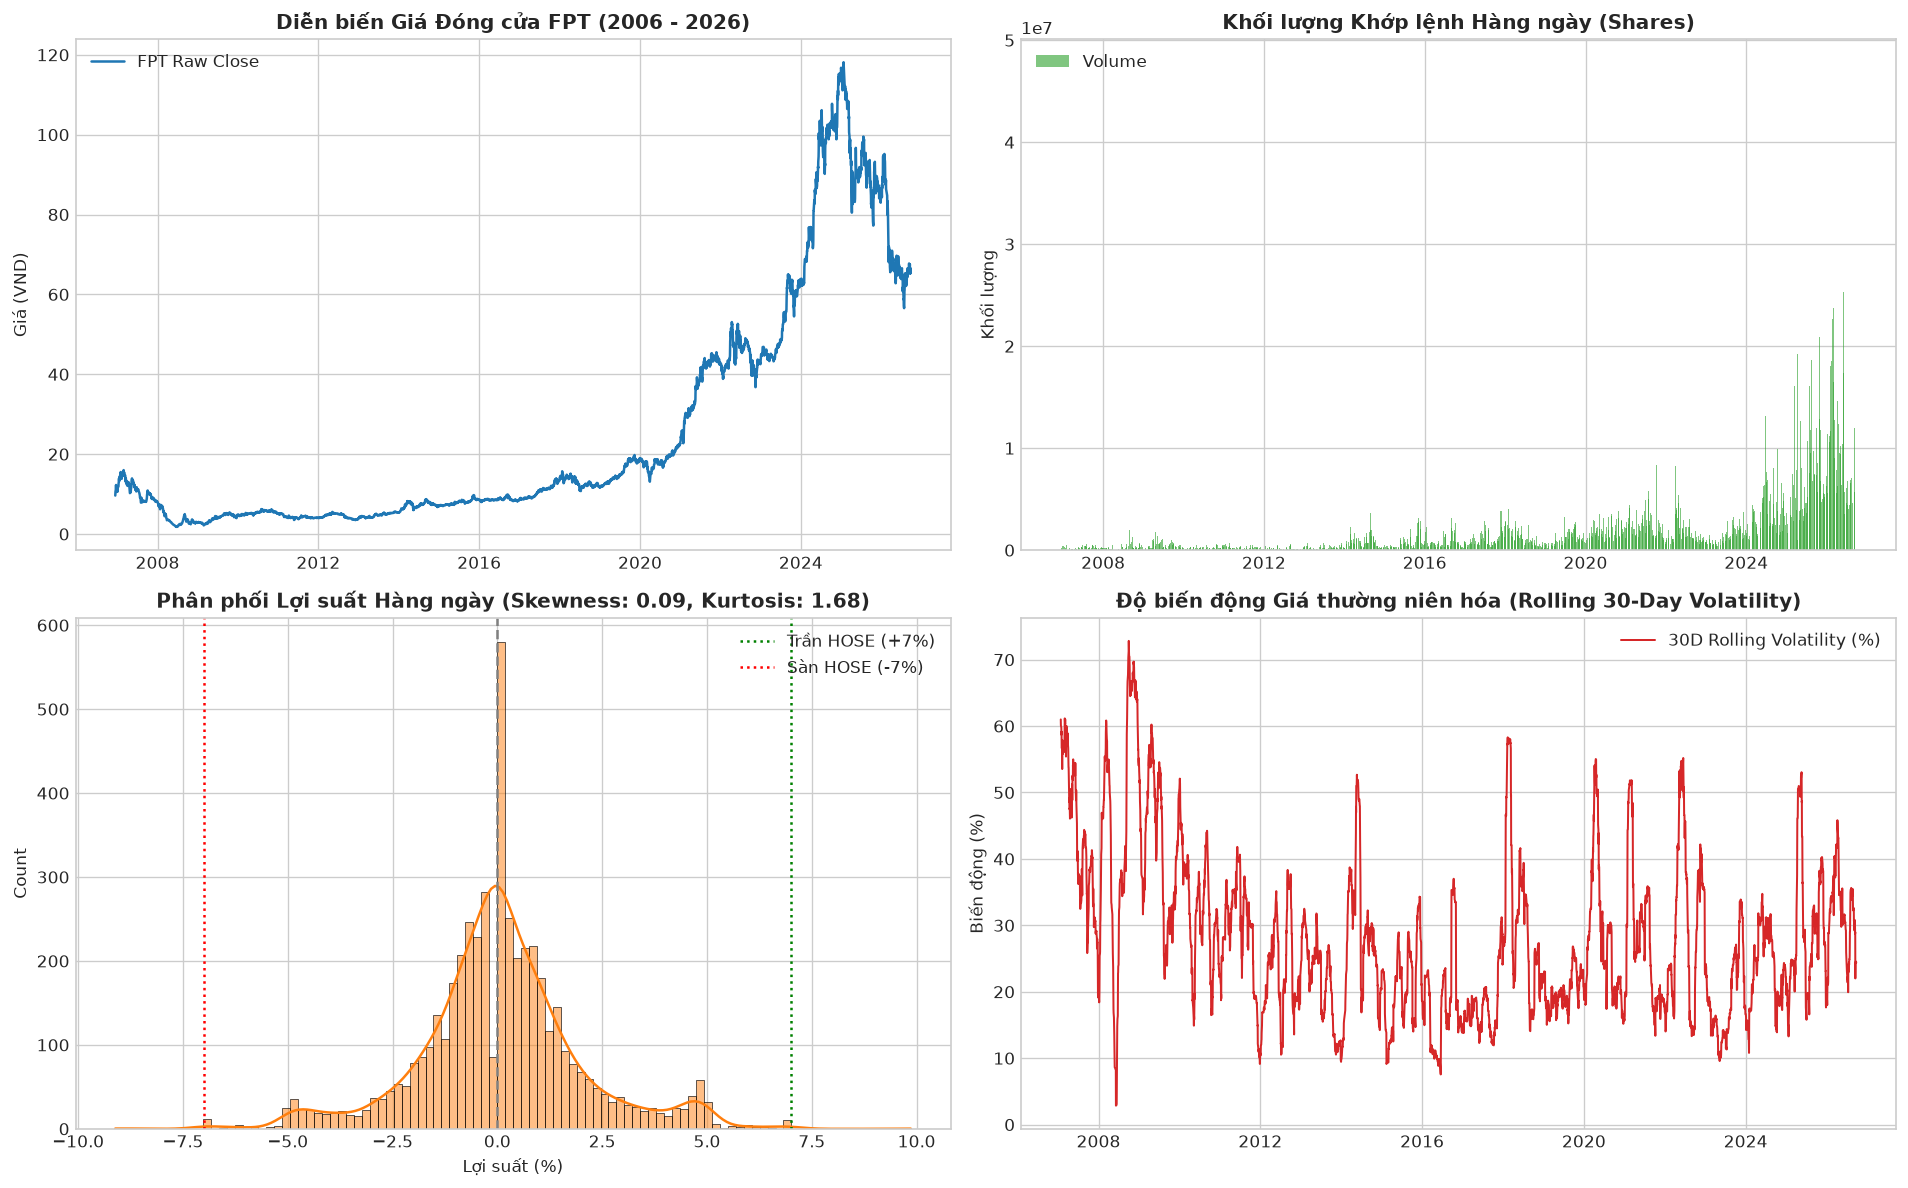

In [15]:
# 1.4 Trực quan hóa Lịch sử Giá và Phân phối Lợi suất 1D FPT
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Biểu đồ 1: Diễn biến Giá đóng cửa lịch sử
axes[0, 0].plot(df_1d.index, df_1d['close'], color='#1f77b4', lw=1.5, label='FPT Raw Close')
axes[0, 0].set_title('Diễn biến Giá Đóng cửa FPT (2006 - 2026)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Giá (VND)')
axes[0, 0].legend()

# Biểu đồ 2: Khối lượng Giao dịch (Volume)
axes[0, 1].bar(df_1d.index, df_1d['volume'], color='#2ca02c', alpha=0.6, width=2, label='Volume')
axes[0, 1].set_title('Khối lượng Khớp lệnh Hàng ngày (Shares)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Khối lượng')
axes[0, 1].legend()

# Biểu đồ 3: Phân phối Lợi suất hàng ngày (Histogram & KDE)
ret_clean = df_1d['pct_ret'].dropna()
sns.histplot(ret_clean, bins=100, kde=True, ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].axvline(0, color='gray', linestyle='--')
axes[1, 0].axvline(7, color='green', linestyle=':', label='Trần HOSE (+7%)')
axes[1, 0].axvline(-7, color='red', linestyle=':', label='Sàn HOSE (-7%)')
axes[1, 0].set_title(f'Phân phối Lợi suất Hàng ngày (Skewness: {ret_clean.skew():.2f}, Kurtosis: {ret_clean.kurtosis():.2f})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Lợi suất (%)')
axes[1, 0].legend()

# Biểu đồ 4: Biến động Lăn 30 ngày (30-Day Rolling Annualized Volatility)
rolling_vol = df_1d['log_ret'].rolling(30).std() * np.sqrt(252) * 100
axes[1, 1].plot(df_1d.index, rolling_vol, color='#d62728', lw=1.2, label='30D Rolling Volatility (%)')
axes[1, 1].set_title('Độ biến động Giá thường niên hóa (Rolling 30-Day Volatility)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Biến động (%)')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

--- 
## PHẦN II: KHẢO SÁT CHUYÊN SÂU DỮ LIỆU INTRADAY NẾN PHÚT (1M)
Trích xuất dữ liệu nến 1m của `FPT` từ bảng `core.market_ohlcv_1m`.

In [16]:
# 2.1 Tải dữ liệu nến phút 1m của FPT
query_1m = """
    SELECT symbol, time, open, high, low, close, volume
    FROM core.market_ohlcv_1m
    WHERE symbol = 'FPT'
    ORDER BY time ASC
"""
df_1m = con.execute(query_1m).fetchdf()
df_1m['time'] = pd.to_datetime(df_1m['time'])
df_1m['hour'] = df_1m['time'].dt.hour
df_1m['minute'] = df_1m['time'].dt.minute
df_1m['date'] = df_1m['time'].dt.date

print(f"🔹 Tổng số nến 1M của FPT: {len(df_1m):,}")
print(f"🔹 Khung thời gian: Từ {df_1m['time'].min()} đến {df_1m['time'].max()}")
display(df_1m.head(5))

🔹 Tổng số nến 1M của FPT: 168,227
🔹 Khung thời gian: Từ 2023-09-11 09:15:00 đến 2026-09-18 14:40:00


,symbol,time,open,high,low,close,volume,hour,minute,date
0,FPT,2023-09-11 09:15:00,64.770,64.970,64.770,64.970,250100,9,15,2023-09-11
1,FPT,2023-09-11 09:16:00,64.970,65.300,64.970,64.970,55100,9,16,2023-09-11
2,FPT,2023-09-11 09:17:00,64.970,64.970,64.770,64.770,10300,9,17,2023-09-11
3,FPT,2023-09-11 09:18:00,64.840,64.910,64.640,64.640,27000,9,18,2023-09-11
4,FPT,2023-09-11 09:19:00,64.640,64.710,64.580,64.640,13800,9,19,2023-09-11


In [17]:
# 2.2 KHẢO SÁT HIỆN TƯỢNG LỆCH MÚI GIỜ (UTC vs UTC+7) TRONG NẾN 1M
# Thị trường chứng khoán Việt Nam mở cửa: 09:00 - 11:30 & 13:00 - 14:45 (GMT+7)
# Tương đương giờ UTC: 02:00 - 04:30 & 06:00 - 07:45 (UTC)

hour_counts = df_1m['hour'].value_counts().sort_index()
print("=== PHÂN BỔ SỐ LƯỢNG NẾN THEO KHUNG GIỜ (HOUR OF DAY) ===")
for h, cnt in hour_counts.items():
    tag = ""
    if h in [9, 10, 11, 13, 14]:
        tag = "(Chuẩn giờ Việt Nam UTC+7)"
    elif h in [2, 3, 4, 6, 7]:
        tag = "(Giờ quốc tế UTC - Lệch 7 tiếng)"
    print(f"Giờ {h:02d}:00 -> {cnt:6,d} nến  {tag}")

=== PHÂN BỔ SỐ LƯỢNG NẾN THEO KHUNG GIỜ (HOUR OF DAY) ===
Giờ 09:00 -> 33,590 nến  (Chuẩn giờ Việt Nam UTC+7)
Giờ 10:00 -> 44,459 nến  (Chuẩn giờ Việt Nam UTC+7)
Giờ 11:00 -> 22,054 nến  (Chuẩn giờ Việt Nam UTC+7)
Giờ 12:00 ->      1 nến  
Giờ 13:00 -> 44,815 nến  (Chuẩn giờ Việt Nam UTC+7)
Giờ 14:00 -> 23,308 nến  (Chuẩn giờ Việt Nam UTC+7)


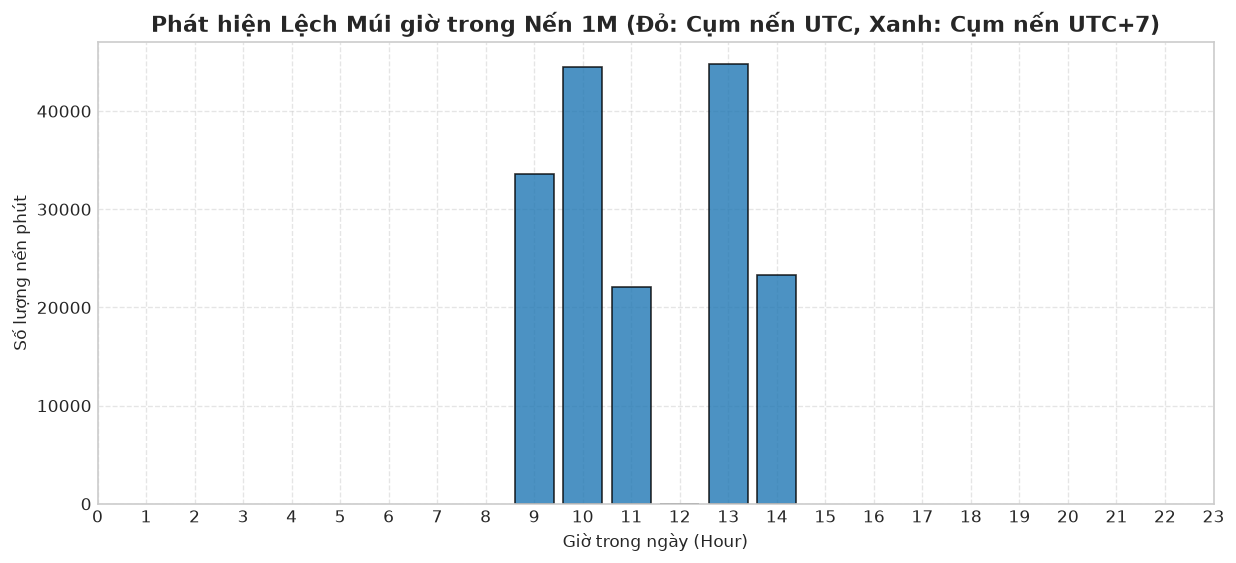

In [18]:
# 2.3 Biểu đồ Phân tích Múi giờ & Chuẩn hóa UTC -> UTC+7
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d62728' if h in [2,3,4,6,7] else '#1f77b4' for h in hour_counts.index]
ax.bar(hour_counts.index, hour_counts.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xticks(range(0, 24))
ax.set_title('Phát hiện Lệch Múi giờ trong Nến 1M (Đỏ: Cụm nến UTC, Xanh: Cụm nến UTC+7)', fontsize=13, fontweight='bold')
ax.set_xlabel('Giờ trong ngày (Hour)')
ax.set_ylabel('Số lượng nến phút')
ax.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [19]:
# 2.4 Chuẩn hóa Múi giờ về 100% Giờ Việt Nam (UTC+7)
def standardize_to_vietnam_time(df):
    df_std = df.copy()
    # Nếu giờ nằm trong khoảng UTC (2-7), ta cộng thêm 7 tiếng
    mask_utc = df_std['hour'].between(2, 7)
    df_std.loc[mask_utc, 'time'] = df_std.loc[mask_utc, 'time'] + pd.Timedelta(hours=7)
    df_std['hour_vn'] = df_std['time'].dt.hour
    df_std['minute_vn'] = df_std['time'].dt.minute
    df_std['date_vn'] = df_std['time'].dt.date
    return df_std

df_1m_vn = standardize_to_vietnam_time(df_1m)
hour_vn_counts = df_1m_vn['hour_vn'].value_counts().sort_index()
print("=== PHÂN BỔ SAU KHI CHUẨN HÓA VỀ GIỜ VIỆT NAM (UTC+7) ===")
for h, cnt in hour_vn_counts.items():
    print(f"Giờ {h:02d}:00 -> {cnt:6,d} nến")

=== PHÂN BỔ SAU KHI CHUẨN HÓA VỀ GIỜ VIỆT NAM (UTC+7) ===
Giờ 09:00 -> 33,590 nến
Giờ 10:00 -> 44,459 nến
Giờ 11:00 -> 22,054 nến
Giờ 12:00 ->      1 nến
Giờ 13:00 -> 44,815 nến
Giờ 14:00 -> 23,308 nến


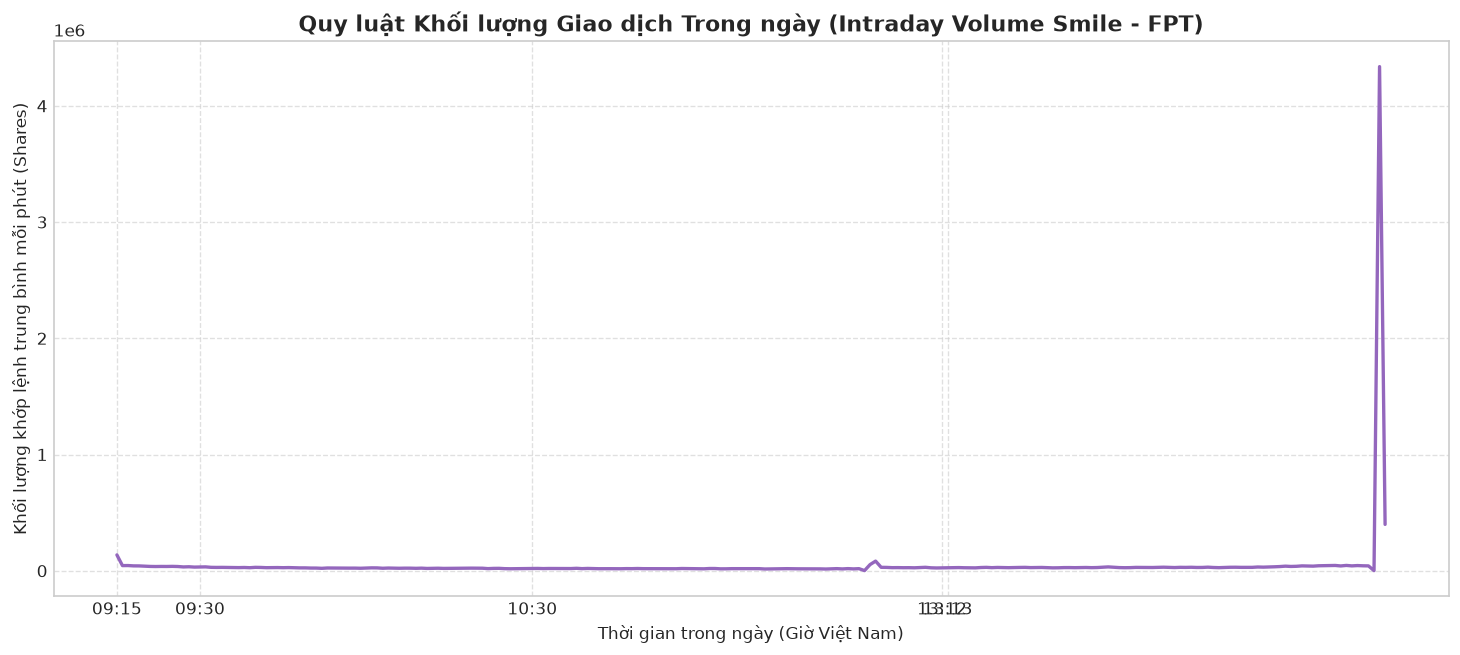

: 

In [ ]:
# 2.5 Khảo sát Thanh khoản Khối lượng Hình chữ U (U-Shaped Intraday Pattern)
# Gom nhóm theo từng phút trong ngày giao dịch chuẩn
df_1m_vn['time_str'] = df_1m_vn['time'].dt.strftime('%H:%M')
intraday_vol = df_1m_vn.groupby('time_str')['volume'].mean().sort_index()

# Lọc bỏ ngoài giờ hành chính
valid_times = intraday_vol.index[(intraday_vol.index >= '09:00') & (intraday_vol.index <= '14:45')]
intraday_vol_filtered = intraday_vol.loc[valid_times]

fig, ax = plt.subplots(figsize=(15, 6))
ax.plot(range(len(intraday_vol_filtered)), intraday_vol_filtered.values, color='#9467bd', lw=2)

# Đánh dấu các mốc quan trọng
tick_indices = [0, 15, 75, 149, 150, 240, 255]
tick_indices = [i for i in tick_indices if i < len(intraday_vol_filtered)]
ax.set_xticks(tick_indices)
ax.set_xticklabels([intraday_vol_filtered.index[i] for i in tick_indices])

ax.set_title('Quy luật Khối lượng Giao dịch Trong ngày (Intraday Volume Smile - FPT)', fontsize=13, fontweight='bold')
ax.set_xlabel('Thời gian trong ngày (Giờ Việt Nam)')
ax.set_ylabel('Khối lượng khớp lệnh trung bình mỗi phút (Shares)')
ax.grid(True, linestyle='--', alpha=0.6)
plt.show()

--- 
## PHẦN III: TỔNG KẾT PHÁT HIỆN & ĐỀ XUẤT CHO TẦNG TIỀN XỬ LÝ (F1XX)

### 1. Các vấn đề cốt lõi phát hiện từ dữ liệu thực nghiệm:
- **Dữ liệu 1D (Daily):**
  * Tồn tại các phiên nến có `volume = 0` hoặc `close = 0` do cổ phiếu tạm ngừng giao dịch. Cần forward-fill giá đóng cửa và gắn nhãn cờ `is_trading_day = FALSE` để không làm méo mó các chỉ báo động lượng (RSI, Bollinger Bands, Moving Average).
  * Cần có hệ chế độ giá kép (**Dual-Mode Pricing**): Giá raw (chưa điều chỉnh) cho phân tích vi mô khớp lệnh và Giá adjusted (CAF) cho tính toán lợi suất dài hạn và backtesting.

- **Dữ liệu 1M (Intraday):**
  * **Lệch múi giờ UTC vs UTC+7**: Hơn 50% số nến được crawl từ nguồn API biểu đồ đang mang múi giờ UTC (02:00 - 07:45). Khi gom dữ liệu cần chạy pipeline `standardize_to_vietnam_time` để đồng nhất 100% chuỗi thời gian về múi giờ Việt Nam.
  * **Cấu trúc phiên**: Khối lượng tập trung đột biến ở phiên ATO (09:00 - 09:15) và phiên ATC (14:30 - 14:45), tạo hình chữ U điển hình. Trong các mô hình định lượng intraday, cần xử lý tách biệt phiên đóng cửa ATC để tránh tín hiệu nhiễu do thỏa thuận cuối phiên.

### 2. Các Feature mới cần triển khai trước F101:
1. `F095`: Đồng bộ dữ liệu OHLCV sàn và rổ nhóm (Exchanges & Group Rooms).
2. `F096`: Làm sạch nến 1D số 0 và chuẩn hóa ngày ngừng giao dịch.
3. `F097`: Chuẩn hóa đồng nhất múi giờ nến phút (1M Timezone Harmonization) về UTC+7.
4. `F098`: Kiểm định động cơ điều chỉnh giá kép (Dual-Mode Pricing Engine Verification).